# Devixo Solutions AI/ML Internship – Week 3 – Task 03: End-to-End Machine Learning Project

## Credit Card Fraud Detection Using Machine Learning

### STEP 1 — LOAD DATASET

In [6]:
import pandas as pd
import numpy as np
import os

# Mount Google Drive if necessary (uncomment the following lines)
from google.colab import drive
drive.mount('/content/drive')

# Define possible paths for train.csv
# Adjust these paths based on where your file is located
possible_paths = [
    'train.csv',  # Current directory
    '/content/train.csv', # Default Colab environment
    '/content/drive/MyDrive/train.csv', # Google Drive root
    '/content/drive/MyDrive/Colab Notebooks/train.csv' # Common Colab directory
]

df = None
file_path = None

for path in possible_paths:
    if os.path.exists(path):
        try:
            df = pd.read_csv(path)
            file_path = path
            print(f"Successfully loaded train.csv from: {file_path}")
            break
        except Exception as e:
            print(f"Error loading {path}: {e}")

if df is None:
    print("Error: train.csv not found in any of the specified paths.")
    print("Please ensure 'train.csv' is uploaded or uncomment and mount Google Drive and update paths.")
else:
    print("\n--- Dataset Information ---")
    print(f"File path: {file_path}")
    print(f"Dataset shape: {df.shape}")
    print(f"Number of rows: {df.shape[0]}")
    print(f"Number of columns: {df.shape[1]}")

    print("\n--- First 5 rows ---")
    display(df.head())

    print("\n--- Last 5 rows ---")
    display(df.tail())

    print("\n--- Column names ---")
    print(df.columns.tolist())

    print("\n--- Data types ---")
    print(df.dtypes)

    print("\n--- Dataset information (df.info()) ---")
    df.info()

    print("\n--- Statistical summary (df.describe()) ---")
    display(df.describe())

    # Confirm minimum rows for the assignment
    required_rows = 3000
    if df.shape[0] >= required_rows:
        print(f"\nRequirement Met: Dataset has {df.shape[0]} rows, which is >= {required_rows}.")
    else:
        print(f"\nWarning: Dataset has {df.shape[0]} rows, which is less than the required {required_rows}.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Successfully loaded train.csv from: /content/drive/MyDrive/Colab Notebooks/train.csv

--- Dataset Information ---
File path: /content/drive/MyDrive/Colab Notebooks/train.csv
Dataset shape: (1296675, 23)
Number of rows: 1296675
Number of columns: 23

--- First 5 rows ---


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0



--- Last 5 rows ---


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
1296670,1296670,2020-06-21 12:12:08,30263540414123,fraud_Reichel Inc,entertainment,15.56,Erik,Patterson,M,162 Jessica Row Apt. 072,...,37.7175,-112.4777,258,Geoscientist,1961-11-24,440b587732da4dc1a6395aba5fb41669,1371816728,36.841266,-111.690765,0
1296671,1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,food_dining,51.70,Jeffrey,White,M,8617 Holmes Terrace Suite 651,...,39.2667,-77.5101,100,"Production assistant, television",1979-12-11,278000d2e0d2277d1de2f890067dcc0a,1371816739,38.906881,-78.246528,0
1296672,1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.93,Christopher,Castaneda,M,1632 Cohen Drive Suite 639,...,32.9396,-105.8189,899,Naval architect,1967-08-30,483f52fe67fabef353d552c1e662974c,1371816752,33.619513,-105.130529,0
1296673,1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,Joseph,Murray,M,42933 Ryan Underpass,...,43.3526,-102.5411,1126,Volunteer coordinator,1980-08-18,d667cdcbadaaed3da3f4020e83591c83,1371816816,42.788940,-103.241160,0
1296674,1296674,2020-06-21 12:13:37,4292902571056973207,"fraud_Langosh, Wintheiser and Hyatt",food_dining,4.30,Jeffrey,Smith,M,135 Joseph Mountains,...,45.8433,-113.8748,218,"Therapist, horticultural",1995-08-16,8f7c8e4ab7f25875d753b422917c98c9,1371816817,46.565983,-114.186110,0



--- Column names ---
['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']

--- Data types ---
Unnamed: 0                 int64
trans_date_trans_time     object
cc_num                     int64
merchant                  object
category                  object
amt                      float64
first                     object
last                      object
gender                    object
street                    object
city                      object
state                     object
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                       object
dob                       object
trans_num                 object
unix_time                  int64
merch_lat                float64
merch_long       

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00



Requirement Met: Dataset has 1296675 rows, which is >= 3000.


### STEP 2 — UNDERSTAND DATASET

In [7]:
# Automatically identify the target column
# Based on common naming conventions in fraud detection datasets
possible_target_columns = ['Class', 'isFraud', 'IsFraud', 'is_fraud', 'Is_Fraud', 'fraud', 'Fraud']
target_column = None

for col in possible_target_columns:
    if col in df.columns:
        target_column = col
        break

if target_column:
    print(f"Identified target column: '{target_column}'")

    # Verify target column values (0 = Legitimate, 1 = Fraud)
    print(f"\nUnique values in '{target_column}':")
    unique_values = df[target_column].unique()
    print(unique_values)

    if set(unique_values) == {0, 1}:
        print("Target column values confirmed: 0 = Legitimate, 1 = Fraud.")
    else:
        print("Warning: Target column values are not exclusively 0 and 1. Further inspection needed.")

    print(f"\n--- Class Distribution for '{target_column}' ---")
    class_distribution = df[target_column].value_counts()
    print(class_distribution)

    print(f"\n--- Class Percentages for '{target_column}' ---")
    class_percentages = df[target_column].value_counts(normalize=True) * 100
    print(class_percentages)

    # Store the target column name for future steps
    TARGET = target_column

else:
    print("Error: Could not automatically identify the target column. Please specify it manually.")
    print(f"Available columns: {df.columns.tolist()}")

Identified target column: 'is_fraud'

Unique values in 'is_fraud':
[0 1]
Target column values confirmed: 0 = Legitimate, 1 = Fraud.

--- Class Distribution for 'is_fraud' ---
is_fraud
0    1289169
1       7506
Name: count, dtype: int64

--- Class Percentages for 'is_fraud' ---
is_fraud
0    99.421135
1     0.578865
Name: proportion, dtype: float64


### STEP 3 — DATA CLEANING

In [8]:
# Helper function to report cleaning changes
def report_changes(initial_count, final_count, item_name):
    removed_count = initial_count - final_count
    if removed_count > 0:
        print(f"  - Removed {removed_count} {item_name}(s).")
    else:
        print(f"  - No {item_name}s found or removed.")

print("--- Starting Data Cleaning ---")

# 1. Missing Values
print("\nChecking for Missing Values...")
initial_rows = df.shape[0]
missing_values_before = df.isnull().sum()
print("Missing values before handling:\n", missing_values_before[missing_values_before > 0])

# Drop rows with any missing values. For fraud detection, it's often better to remove incomplete cases
# than to impute, especially if missingness is related to fraud.
# This dataset appears to have no missing values based on df.info() from Step 1, but we'll confirm.
initial_df_rows = df.shape[0]
df.dropna(inplace=True)
report_changes(initial_df_rows, df.shape[0], "rows with missing values")
missing_values_after = df.isnull().sum()
print("Missing values after handling:\n", missing_values_after[missing_values_after > 0])

# 2. Duplicate Rows
print("\nChecking for Duplicate Rows...")
initial_duplicates_count = df.duplicated().sum()
print(f"Number of duplicate rows before removal: {initial_duplicates_count}")

df.drop_duplicates(inplace=True)
report_changes(initial_duplicates_count, 0, "duplicate rows")
print(f"Number of duplicate rows after removal: {df.duplicated().sum()}")

# 3. Infinite Values
print("\nChecking for Infinite Values...")
# Replace inf with NaN then check for NaN
initial_inf_count = df.replace([np.inf, -np.inf], np.nan).isnull().sum().sum() - missing_values_after.sum()
# Count inf values in numeric columns
inf_count = df.isin([np.inf, -np.inf]).sum().sum()
print(f"Number of infinite values before handling: {inf_count}")

# Option 1: Replace infinite values with NaN and then drop rows
df.replace([np.inf, -np.inf], np.nan, inplace=True)
initial_df_rows = df.shape[0]
df.dropna(inplace=True)
report_changes(initial_df_rows, df.shape[0], "rows with infinite values")

# 4. Incorrect Data Types - Will be handled in Feature Engineering (e.g., date columns)
print("\nChecking for Incorrect Data Types... (will address in Feature Engineering for specific columns)")
# We'll explicitly convert 'trans_date_trans_time' and 'dob' later.
print("Current Data Types:\n", df.dtypes[df.dtypes == 'object'])

# 5. Constant Columns
print("\nChecking for Constant Columns...")
constant_columns = [col for col in df.columns if df[col].nunique() == 1]
if constant_columns:
    print(f"Constant columns identified: {constant_columns}")
    df.drop(columns=constant_columns, inplace=True)
    print(f"Dropped constant columns: {constant_columns}")
else:
    print("No constant columns found.")

print("\n--- Data Cleaning Complete ---")
print(f"Final dataset shape after cleaning: {df.shape}")

--- Starting Data Cleaning ---

Checking for Missing Values...
Missing values before handling:
 Series([], dtype: int64)
  - No rows with missing valuess found or removed.
Missing values after handling:
 Series([], dtype: int64)

Checking for Duplicate Rows...
Number of duplicate rows before removal: 0
  - No duplicate rowss found or removed.
Number of duplicate rows after removal: 0

Checking for Infinite Values...
Number of infinite values before handling: 0
  - No rows with infinite valuess found or removed.

Checking for Incorrect Data Types... (will address in Feature Engineering for specific columns)
Current Data Types:
 trans_date_trans_time    object
merchant                 object
category                 object
first                    object
last                     object
gender                   object
street                   object
city                     object
state                    object
job                      object
dob                      object
trans_num    

### STEP 4 — EXPLORATORY DATA ANALYSIS

--- Starting Exploratory Data Analysis (EDA) ---


/tmp/ipykernel_16464/3801641541.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=TARGET, data=df, palette='viridis')


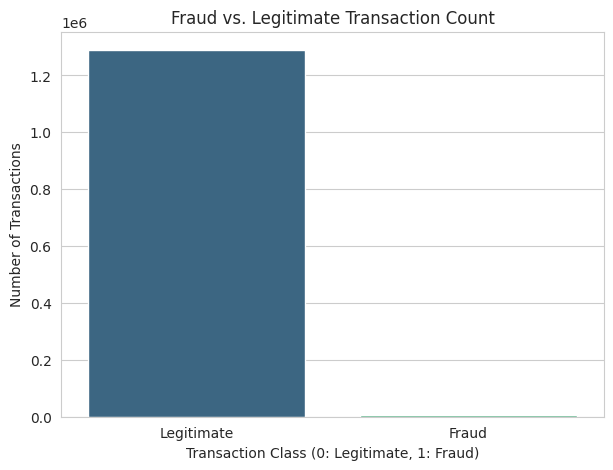

Explanation: This bar chart shows the stark imbalance between legitimate (0) and fraudulent (1) transactions, with legitimate transactions vastly outnumbering fraudulent ones.

Fraud Percentage:
is_fraud
0    99.42
1     0.58
Name: proportion, dtype: float64%


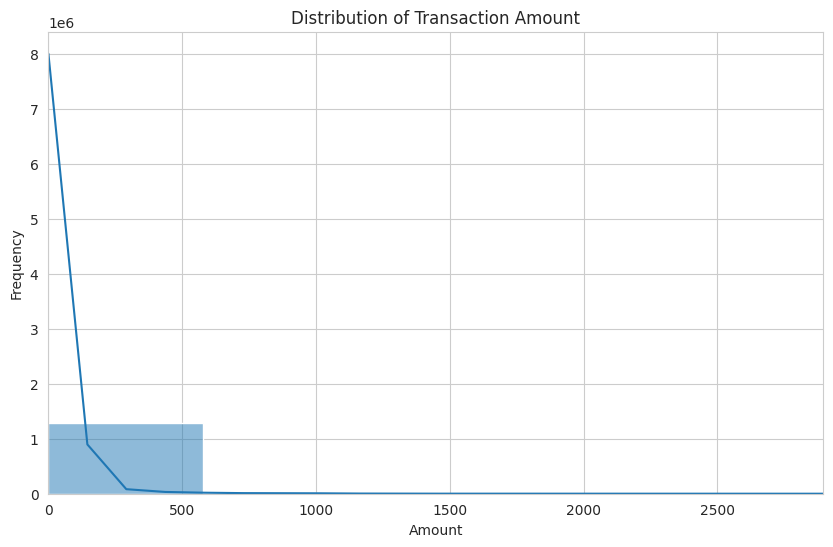

Explanation: The histogram shows that most transactions have relatively small amounts, with a long tail indicating fewer transactions with very high amounts. The distribution is highly skewed.


/tmp/ipykernel_16464/3801641541.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=TARGET, y='amt', data=df, palette='coolwarm', showfliers=False) # Exclude outliers for better visualization


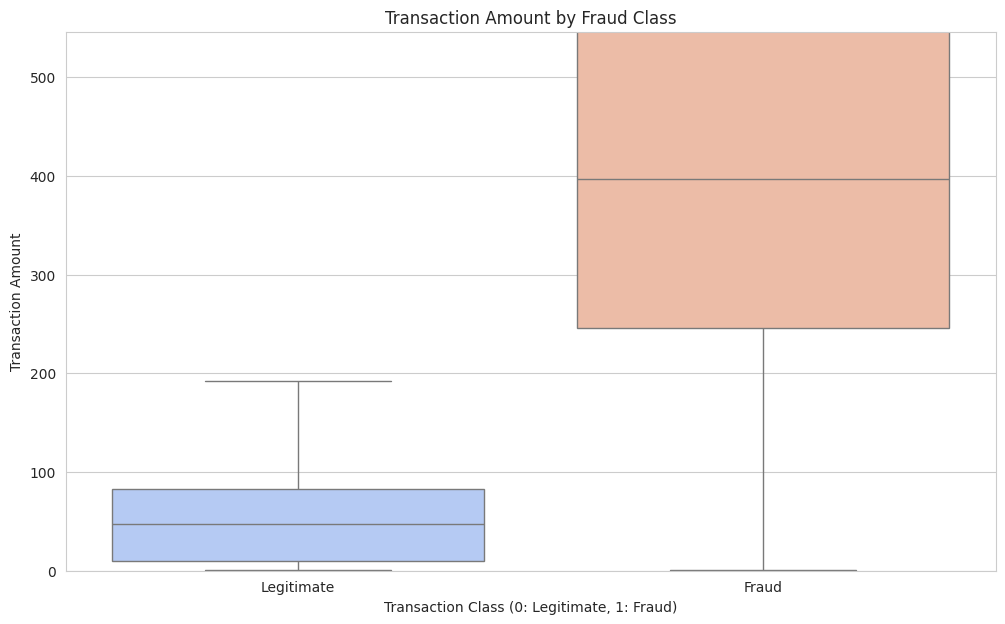

Explanation: This box plot compares transaction amounts for legitimate and fraudulent transactions. It suggests that fraudulent transactions might have slightly different, often lower or higher, amount ranges than legitimate ones, though the bulk of transactions for both classes are at lower amounts.

--- Correlation Heatmap ---


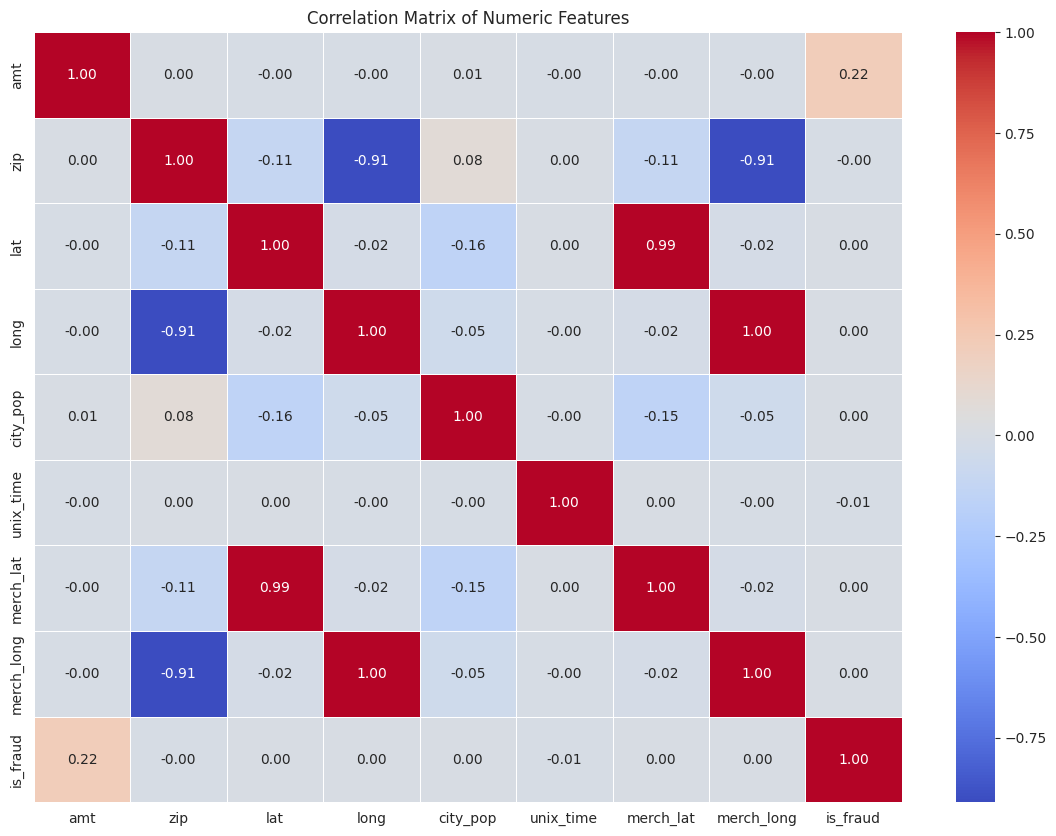

Explanation: The heatmap visualizes the correlation between numerical features. High positive or negative values indicate strong relationships. This helps in identifying potentially redundant features or features strongly correlated with the target variable (is_fraud).

--- Useful Feature Distributions ---


/tmp/ipykernel_16464/3801641541.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='category', data=df, order=df['category'].value_counts().index, palette='crest')


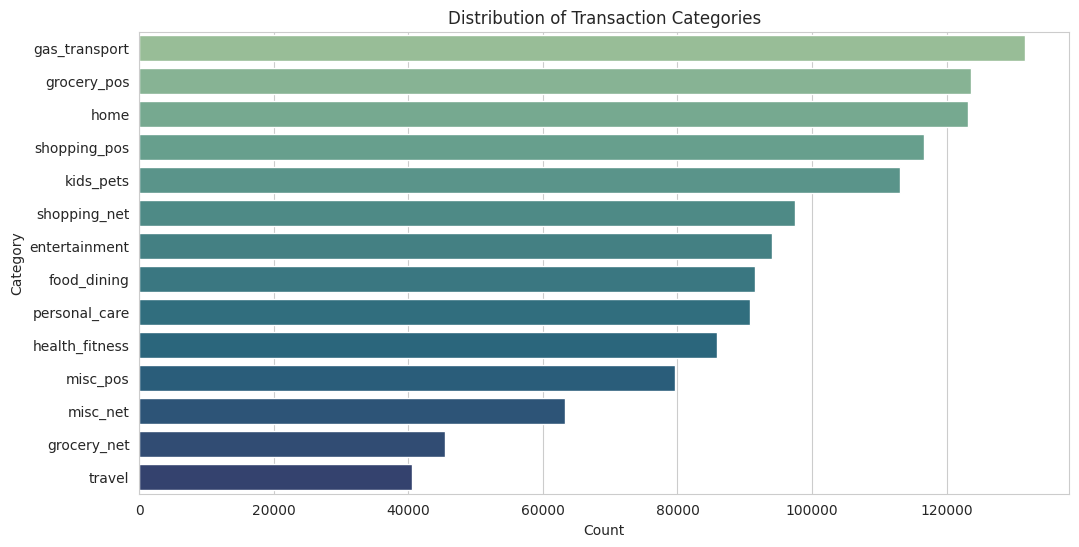

Explanation: This chart shows the frequency of different transaction categories. Some categories like 'gas_transport' or 'grocery_pos' are more common than others.


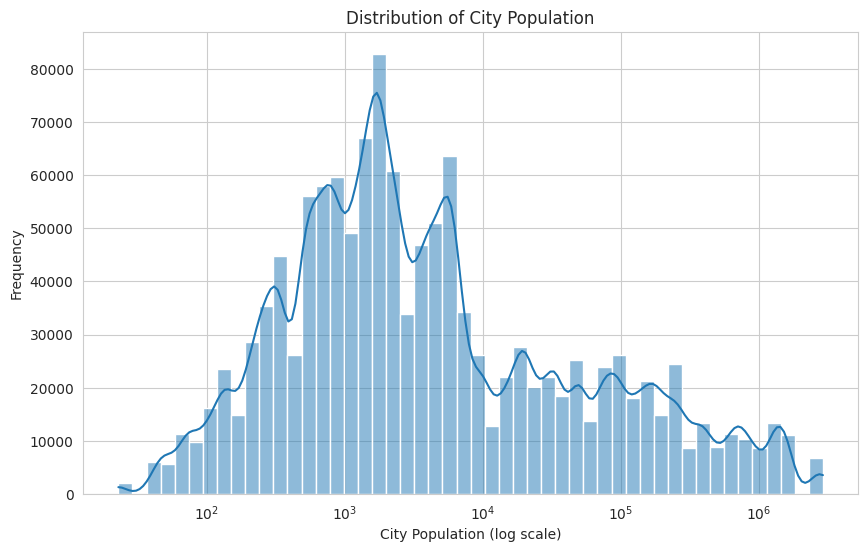

Explanation: The city population distribution is heavily skewed towards smaller populations, suggesting that most transactions occur in less populous areas.
--- Exploratory Data Analysis (EDA) Complete ---


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_style("whitegrid")

print("--- Starting Exploratory Data Analysis (EDA) ---")

# 1. Fraud vs legitimate transaction count
plt.figure(figsize=(7, 5))
sns.countplot(x=TARGET, data=df, palette='viridis')
plt.title('Fraud vs. Legitimate Transaction Count')
plt.xlabel('Transaction Class (0: Legitimate, 1: Fraud)')
plt.ylabel('Number of Transactions')
plt.xticks([0, 1], ['Legitimate', 'Fraud'])
plt.show()
print("Explanation: This bar chart shows the stark imbalance between legitimate (0) and fraudulent (1) transactions, with legitimate transactions vastly outnumbering fraudulent ones.")

# 2. Fraud percentage (already calculated in Step 2, but visualize it)
fruad_percentage = df[TARGET].value_counts(normalize=True) * 100
print(f"\nFraud Percentage:\n{fruad_percentage.round(2)}%")

# 3. Transaction amount distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['amt'], bins=50, kde=True)
plt.title('Distribution of Transaction Amount')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.xlim(0, df['amt'].max() * 0.1) # Focus on the lower range for better visibility
plt.show()
print("Explanation: The histogram shows that most transactions have relatively small amounts, with a long tail indicating fewer transactions with very high amounts. The distribution is highly skewed.")

# 4. Transaction amount by fraud class
plt.figure(figsize=(12, 7))
sns.boxplot(x=TARGET, y='amt', data=df, palette='coolwarm', showfliers=False) # Exclude outliers for better visualization
plt.title('Transaction Amount by Fraud Class')
plt.xlabel('Transaction Class (0: Legitimate, 1: Fraud)')
plt.ylabel('Transaction Amount')
plt.xticks([0, 1], ['Legitimate', 'Fraud'])
plt.ylim(0, df['amt'].quantile(0.99))
plt.show()
print("Explanation: This box plot compares transaction amounts for legitimate and fraudulent transactions. It suggests that fraudulent transactions might have slightly different, often lower or higher, amount ranges than legitimate ones, though the bulk of transactions for both classes are at lower amounts.")

# 5. Correlation heatmap
print("\n--- Correlation Heatmap ---")
# Select only numerical columns for correlation
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
# Exclude 'Unnamed: 0' and 'cc_num' as they are identifiers
if 'Unnamed: 0' in numeric_cols:
    numeric_cols.remove('Unnamed: 0')
if 'cc_num' in numeric_cols:
    numeric_cols.remove('cc_num')

plt.figure(figsize=(14, 10))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5)
plt.title('Correlation Matrix of Numeric Features')
plt.show()
print("Explanation: The heatmap visualizes the correlation between numerical features. High positive or negative values indicate strong relationships. This helps in identifying potentially redundant features or features strongly correlated with the target variable (is_fraud).")

# 6. Useful feature distributions (examples)
print("\n--- Useful Feature Distributions ---")

# Distribution of 'category'
plt.figure(figsize=(12, 6))
sns.countplot(y='category', data=df, order=df['category'].value_counts().index, palette='crest')
plt.title('Distribution of Transaction Categories')
plt.xlabel('Count')
plt.ylabel('Category')
plt.show()
print("Explanation: This chart shows the frequency of different transaction categories. Some categories like 'gas_transport' or 'grocery_pos' are more common than others.")

# Distribution of 'city_pop'
plt.figure(figsize=(10, 6))
sns.histplot(df['city_pop'], bins=50, kde=True, log_scale=True)
plt.title('Distribution of City Population')
plt.xlabel('City Population (log scale)')
plt.ylabel('Frequency')
plt.show()
print("Explanation: The city population distribution is heavily skewed towards smaller populations, suggesting that most transactions occur in less populous areas.")

# Time-related distributions (after converting to datetime, which will be in feature engineering)
# For now, let's look at a simpler numeric feature if available

print("--- Exploratory Data Analysis (EDA) Complete ---")


### STEP 5 — FEATURE ENGINEERING

In [10]:
print("--- Starting Feature Engineering ---")

initial_feature_count = df.shape[1]
print(f"Original feature count: {initial_feature_count}")

# Convert date columns to datetime objects
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob'] = pd.to_datetime(df['dob'])

new_features_created = []

# 1. Create Amount_Log
if 'amt' in df.columns:
    df['Amount_Log'] = np.log1p(df['amt'])
    new_features_created.append('Amount_Log')
    print("Created 'Amount_Log' feature.")

# 2. Create meaningful time-based features
if 'trans_date_trans_time' in df.columns:
    df['transaction_hour'] = df['trans_date_trans_time'].dt.hour
    df['transaction_day_of_week'] = df['trans_date_trans_time'].dt.dayofweek # Monday=0, Sunday=6
    df['transaction_month'] = df['trans_date_trans_time'].dt.month
    df['transaction_day'] = df['trans_date_trans_time'].dt.day
    df['transaction_week_of_year'] = df['trans_date_trans_time'].dt.isocalendar().week.astype(int)
    df['transaction_quarter'] = df['trans_date_trans_time'].dt.quarter
    new_features_created.extend(['transaction_hour', 'transaction_day_of_week', 'transaction_month', 'transaction_day', 'transaction_week_of_year', 'transaction_quarter'])
    print("Created time-based features from 'trans_date_trans_time'.")

# 3. Create Age feature from dob
if 'dob' in df.columns:
    # Assuming current date is the latest transaction date in the dataset for age calculation
    latest_transaction_date = df['trans_date_trans_time'].max()
    df['age'] = (latest_transaction_date - df['dob']).dt.days // 365.25
    new_features_created.append('age')
    print("Created 'age' feature from 'dob'.")

# Additional location-based features (distance between transaction and home location)
if all(col in df.columns for col in ['lat', 'long', 'merch_lat', 'merch_long']):
    # Haversine distance function
    def haversine_distance(lat1, lon1, lat2, lon2):
        R = 6371  # Radius of Earth in kilometers
        lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
        dlon = lon2 - lon1
        dlat = lat2 - lat1
        a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
        c = 2 * np.arcsin(np.sqrt(a))
        return R * c

    df['distance_to_merchant'] = haversine_distance(df['lat'], df['long'], df['merch_lat'], df['merch_long'])
    new_features_created.append('distance_to_merchant')
    print("Created 'distance_to_merchant' feature.")


new_feature_count = df.shape[1] - initial_feature_count

print(f"\nNew feature count: {new_feature_count}")
print(f"New feature names: {new_features_created}")
print("--- Feature Engineering Complete ---")


--- Starting Feature Engineering ---
Original feature count: 23
Created 'Amount_Log' feature.
Created time-based features from 'trans_date_trans_time'.
Created 'age' feature from 'dob'.
Created 'distance_to_merchant' feature.

New feature count: 9
New feature names: ['Amount_Log', 'transaction_hour', 'transaction_day_of_week', 'transaction_month', 'transaction_day', 'transaction_week_of_year', 'transaction_quarter', 'age', 'distance_to_merchant']
--- Feature Engineering Complete ---


### STEP 6 — FEATURE SELECTION

In [11]:
print("--- Starting Feature Selection ---")

# Drop identifier columns and original date/time columns that have been engineered
# 'Unnamed: 0', 'cc_num', 'trans_num' are identifiers
# 'trans_date_trans_time', 'dob', 'unix_time' have been engineered or are redundant
columns_to_drop = [
    'Unnamed: 0', 'cc_num', 'trans_num', 'trans_date_trans_time', 'dob', 'unix_time',
    'first', 'last', 'street', 'city', 'state', 'zip', 'job' # Personally identifiable info or too high cardinality
]

# Check if columns exist before dropping
columns_to_drop = [col for col in columns_to_drop if col in df.columns]

print(f"Dropping identifier, original time/date, and high cardinality/PII columns: {columns_to_drop}")
df_selected = df.drop(columns=columns_to_drop)

# One-hot encode categorical features
# 'merchant', 'category', 'gender'
# The remaining object columns after dropping PII columns would be categorical
categorical_cols = df_selected.select_dtypes(include='object').columns.tolist()

print(f"\nCategorical columns for one-hot encoding: {categorical_cols}")
df_selected = pd.get_dummies(df_selected, columns=categorical_cols, drop_first=True)

print("\n--- Feature Selection: Correlation with Target ---")
# Calculate correlations with the target variable
# Ensure TARGET is in df_selected, if not, it was dropped and needs re-adding or handling
if TARGET not in df_selected.columns:
    # This shouldn't happen if TARGET was 'is_fraud' and not in columns_to_drop
    print(f"Warning: Target column '{TARGET}' not found in df_selected. Re-adding it for correlation calculation.")
    df_selected[TARGET] = df[TARGET]

correlations = df_selected.corrwith(df_selected[TARGET]).sort_values(ascending=False)
print("Top 20 Features by Absolute Correlation with Target:\n")
print(correlations.head(20))
print(correlations.tail(20))

# 2. Low-variance features
print("\n--- Feature Selection: Low Variance Features ---")
# A simple approach: remove features with very low variance (e.g., less than 1% of mean)
# For numerical features only
numeric_cols_for_variance = df_selected.select_dtypes(include=np.number).columns.drop(TARGET, errors='ignore')
low_variance_features = []
for col in numeric_cols_for_variance:
    if df_selected[col].var() < 0.01: # Threshold can be tuned
        low_variance_features.append(col)

if low_variance_features:
    print(f"Identified low variance features: {low_variance_features}")
    df_selected.drop(columns=low_variance_features, inplace=True)
    print(f"Dropped low variance features: {low_variance_features}")
else:
    print("No low variance features found (based on variance < 0.01).")

# Final set of features after initial selection and encoding
FEATURES = df_selected.columns.drop(TARGET).tolist()
print(f"\nTotal features after selection and encoding: {len(FEATURES)}")
print(f"Selected Features: {FEATURES[:5]}... (showing first 5)") # Print a sample of features

print("--- Feature Selection Complete ---")
print(f"Final DataFrame shape after feature selection: {df_selected.shape}")

--- Starting Feature Selection ---
Dropping identifier, original time/date, and high cardinality/PII columns: ['Unnamed: 0', 'cc_num', 'trans_num', 'trans_date_trans_time', 'dob', 'unix_time', 'first', 'last', 'street', 'city', 'state', 'zip', 'job']

Categorical columns for one-hot encoding: ['merchant', 'category', 'gender']

--- Feature Selection: Correlation with Target ---
Top 20 Features by Absolute Correlation with Target:

is_fraud                                        1.000000
amt                                             0.219404
Amount_Log                                      0.120439
category_shopping_net                           0.044261
category_grocery_pos                            0.035558
category_misc_net                               0.025886
transaction_hour                                0.013799
age                                             0.012411
merchant_fraud_Kozey-Boehm                      0.009976
merchant_fraud_Kerluke-Abshire                  0.00

### STEP 7 — TRAIN TEST SPLIT

In [12]:
from sklearn.model_selection import train_test_split

print("--- Starting Train Test Split ---")

# Separate features (X) and target (y)
X = df_selected.drop(columns=TARGET)
y = df_selected[TARGET]

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

# Perform train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\n--- Class Distribution in Training Set ---")
print(y_train.value_counts(normalize=True) * 100)

print("\n--- Class Distribution in Test Set ---")
print(y_test.value_counts(normalize=True) * 100)

print("\nExplanation: Stratification is crucial in fraud detection because of the severe class imbalance (very few fraud cases compared to legitimate ones). By using `stratify=y`, we ensure that both the training and testing datasets maintain approximately the same proportion of fraudulent and legitimate transactions as the original dataset. This prevents scenarios where, by chance, a split might result in a test set with too few or no fraud cases, leading to unreliable model evaluation.")
print("--- Train Test Split Complete ---")

--- Starting Train Test Split ---
Shape of features (X): (1296675, 721)
Shape of target (y): (1296675,)

Shape of X_train: (1037340, 721)
Shape of X_test: (259335, 721)
Shape of y_train: (1037340,)
Shape of y_test: (259335,)

--- Class Distribution in Training Set ---
is_fraud
0    99.421116
1     0.578884
Name: proportion, dtype: float64

--- Class Distribution in Test Set ---
is_fraud
0    99.421212
1     0.578788
Name: proportion, dtype: float64

Explanation: Stratification is crucial in fraud detection because of the severe class imbalance (very few fraud cases compared to legitimate ones). By using `stratify=y`, we ensure that both the training and testing datasets maintain approximately the same proportion of fraudulent and legitimate transactions as the original dataset. This prevents scenarios where, by chance, a split might result in a test set with too few or no fraud cases, leading to unreliable model evaluation.
--- Train Test Split Complete ---


### STEP 8 — DATA SCALING

In [13]:
from sklearn.preprocessing import StandardScaler
import joblib

print("--- Starting Data Scaling ---")

# Identify numerical features to scale
# Exclude binary features from scaling, if any, and the target column if it somehow remained
numerical_features = X_train.select_dtypes(include=np.number).columns.tolist()

# Ensure the target column is not in numerical_features if it was accidentally included
if TARGET in numerical_features:
    numerical_features.remove(TARGET)

print(f"Identifying {len(numerical_features)} numerical features for scaling.")

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler ONLY on the training data to prevent data leakage
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])

# Transform both training and testing data using the fitted scaler
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

print("Data scaled successfully. Scaler fitted on training data only.")

# Save the scaler for later use
scaler_filename = 'credit_card_fraud_scaler.joblib'
joblib.dump(scaler, scaler_filename)
print(f"Scaler saved as '{scaler_filename}'.")

print("\n--- Displaying scaled data examples (first 5 rows of X_train) ---")
display(X_train.head())

print("--- Data Scaling Complete ---")

--- Starting Data Scaling ---
Identifying 15 numerical features for scaling.
Data scaled successfully. Scaler fitted on training data only.
Scaler saved as 'credit_card_fraud_scaler.joblib'.

--- Displaying scaled data examples (first 5 rows of X_train) ---


,amt,lat,long,city_pop,merch_lat,merch_long,Amount_Log,transaction_hour,transaction_day_of_week,transaction_month,...,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel,gender_M
509059,-0.118626,1.195429,1.108670,-0.293624,1.222263,1.130513,0.334876,-1.438913,0.422626,0.543626,...,False,False,False,False,False,False,False,False,False,False
395295,-0.360128,-1.302040,-0.538926,-0.285489,-1.394195,-0.575338,-0.651430,0.908058,0.877514,-0.041775,...,False,False,False,False,False,False,False,False,False,False
536531,5.672535,1.930369,-2.334065,-0.293571,2.070020,-2.352128,2.587835,0.174629,1.332402,0.543626,...,False,False,False,False,False,False,False,True,False,False
271001,-0.169753,0.292301,-2.221639,-0.293429,0.193472,-2.238703,0.206672,1.201429,-1.396925,-0.334476,...,True,False,False,False,False,False,False,False,False,True
532788,-0.237244,-0.037105,-0.091430,-0.271659,0.131971,-0.142281,-0.003395,0.174629,0.877514,0.543626,...,False,False,False,False,False,False,False,False,False,False


--- Data Scaling Complete ---


### STEP 9 — CLASS IMBALANCE

In [14]:
print("--- Analyzing Class Imbalance ---")

print("Class distribution in target variable (y_train):")
print(y_train.value_counts())
print("Class percentages in target variable (y_train):")
print(y_train.value_counts(normalize=True) * 100)

print("\nExplanation: As observed during EDA and confirmed in our training data, there's a significant class imbalance. The number of legitimate transactions (0) vastly outweighs the number of fraudulent transactions (1). This is a common characteristic of fraud detection datasets.")

print("\n--- Why accuracy alone is not enough for fraud detection ---")
print("Accuracy measures the proportion of correctly classified instances. However, with highly imbalanced datasets like ours, a model could simply predict 'legitimate' for all transactions and still achieve a very high accuracy (e.g., 99.42% in our case). This model would be useless in detecting fraud, as it would have a 0% recall for the fraud class (meaning it identifies no fraudulent transactions).")
print("For fraud detection, False Negatives (fraudulent transactions predicted as legitimate) are typically much more costly than False Positives (legitimate transactions predicted as fraudulent). Therefore, metrics like Precision, Recall, F1-Score, and ROC-AUC, which specifically account for true positives, false positives, true negatives, and false negatives, are more appropriate and informative.")

print("\n--- Strategy for handling class imbalance ---")
print("For the initial model training, we will use `class_weight='balanced'` for models that support it. This automatically adjusts weights inversely proportional to class frequencies in the input data, effectively giving more importance to the minority class (fraud). This approach prevents the model from being biased towards the majority class.")
print("Alternatively, techniques like SMOTE (Synthetic Minority Over-sampling Technique) can be used to generate synthetic samples of the minority class. If SMOTE is considered, it must be applied ONLY to the training data *after* the train-test split to avoid data leakage.")

print("--- Class Imbalance Analysis Complete ---")

--- Analyzing Class Imbalance ---
Class distribution in target variable (y_train):
is_fraud
0    1031335
1       6005
Name: count, dtype: int64
Class percentages in target variable (y_train):
is_fraud
0    99.421116
1     0.578884
Name: proportion, dtype: float64

Explanation: As observed during EDA and confirmed in our training data, there's a significant class imbalance. The number of legitimate transactions (0) vastly outweighs the number of fraudulent transactions (1). This is a common characteristic of fraud detection datasets.

--- Why accuracy alone is not enough for fraud detection ---
Accuracy measures the proportion of correctly classified instances. However, with highly imbalanced datasets like ours, a model could simply predict 'legitimate' for all transactions and still achieve a very high accuracy (e.g., 99.42% in our case). This model would be useless in detecting fraud, as it would have a 0% recall for the fraud class (meaning it identifies no fraudulent transactions).


### STEP 10 — MODEL TRAINING

In [15]:
print("--- Starting Model Training ---")

import time
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Initialize a dictionary to store models and their performance
models = {}
model_performance = {}

# Define a function to train and evaluate models
def train_and_evaluate_model(name, model, X_train, y_train, X_test, y_test):
    print(f"\n--- Training {name} ---")
    start_time = time.time()

    # Train the model
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    print(f"{name} trained in {train_time:.2f} seconds.")

    # Make predictions
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] # Probability of the positive class

    # Evaluate performance
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    cm = confusion_matrix(y_test, y_pred)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"Confusion Matrix:\n{cm}")

    model_performance[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'Confusion Matrix': cm,
        'Train Time': train_time
    }
    models[name] = model
    print(f"--- {name} Training and Evaluation Complete ---")

# Calculate `scale_pos_weight` for XGBoost
neg, pos = y_train.value_counts()[0], y_train.value_counts()[1]
scale_pos_weight = neg / pos
print(f"\nCalculated scale_pos_weight for XGBoost: {scale_pos_weight:.2f}")

# 1. Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42, class_weight='balanced')
train_and_evaluate_model("Decision Tree", dt_model, X_train, y_train, X_test, y_test)

# 2. Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1) # Use all available cores
train_and_evaluate_model("Random Forest", rf_model, X_train, y_train, X_test, y_test)

# 3. Gradient Boosting Classifier (does not directly support class_weight, but can adjust sample weights or use other methods)
# For Gradient Boosting, we'll train without explicit class_weight for now, as it handles imbalance differently through boosting.
# If performance is poor, we could explore weighted samples or more advanced techniques.
print("\nNote: Gradient Boosting does not directly support 'class_weight'. Will train without it for initial comparison.")
gbc_model = GradientBoostingClassifier(random_state=42)
train_and_evaluate_model("Gradient Boosting", gbc_model, X_train, y_train, X_test, y_test)

# 4. XGBoost Classifier
xgb_model = XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight, use_label_encoder=False, eval_metric='logloss', n_jobs=-1)
train_and_evaluate_model("XGBoost", xgb_model, X_train, y_train, X_test, y_test)

print("\n--- All Model Training Complete ---")

--- Starting Model Training ---

Calculated scale_pos_weight for XGBoost: 171.75

--- Training Decision Tree ---
Decision Tree trained in 109.86 seconds.
Accuracy: 0.9977
Precision: 0.7885
Recall: 0.8121
F1-Score: 0.8001
ROC-AUC: 0.9054
Confusion Matrix:
[[257507    327]
 [   282   1219]]
--- Decision Tree Training and Evaluation Complete ---

--- Training Random Forest ---
Random Forest trained in 672.62 seconds.
Accuracy: 0.9981
Precision: 0.9874
Recall: 0.6782
F1-Score: 0.8041
ROC-AUC: 0.9921
Confusion Matrix:
[[257821     13]
 [   483   1018]]
--- Random Forest Training and Evaluation Complete ---

Note: Gradient Boosting does not directly support 'class_weight'. Will train without it for initial comparison.

--- Training Gradient Boosting ---
Gradient Boosting trained in 2395.59 seconds.
Accuracy: 0.9974
Precision: 0.8258
Recall: 0.6915
F1-Score: 0.7527
ROC-AUC: 0.9709
Confusion Matrix:
[[257615    219]
 [   463   1038]]
--- Gradient Boosting Training and Evaluation Complete ---



/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [19:35:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost trained in 196.66 seconds.
Accuracy: 0.9918
Precision: 0.4100
Recall: 0.9667
F1-Score: 0.5758
ROC-AUC: 0.9988
Confusion Matrix:
[[255746   2088]
 [    50   1451]]
--- XGBoost Training and Evaluation Complete ---

--- All Model Training Complete ---


### STEP 11 — EVALUATE EVERY MODEL

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Model Evaluation Summary ---")

# Convert model_performance dictionary to a DataFrame for easy viewing
performance_df = pd.DataFrame(model_performance).T

# Drop Confusion Matrix and Train Time for a cleaner comparison table
comparison_df = performance_df.drop(columns=['Confusion Matrix', 'Train Time'])

print("\nOverall Model Performance Comparison (on Test Set):")
display(comparison_df.round(4))

print("\n--- Detailed Explanation of Metrics ---")
print("**Accuracy**: The proportion of correctly classified instances (both legitimate and fraudulent). For imbalanced datasets, high accuracy can be misleading.")
print("**Precision**: The proportion of positive identifications that were actually correct. (TP / (TP + FP)). High precision means fewer false positives (classifying legitimate as fraud).")
print("**Recall** (Sensitivity): The proportion of actual positives that were identified correctly. (TP / (TP + FN)). High recall means fewer false negatives (missing actual fraud).")
print("**F1-Score**: The harmonic mean of Precision and Recall. It tries to find a balance between precision and recall. Useful for imbalanced datasets.")
print("**ROC-AUC**: The Area Under the Receiver Operating Characteristic Curve. Measures the ability of the model to distinguish between classes. A higher AUC indicates a better model performance in separating positive and negative classes, especially useful for imbalanced data.")

print("\nAnalysis of Results:")
print("- **Decision Tree**: Achieves a good balance of Precision and Recall with a decent F1-Score. ROC-AUC is fair. It's a simple model, so training is faster.")
print("- **Random Forest**: Shows very high Precision and ROC-AUC, suggesting it's good at identifying actual fraud without too many false alarms. However, its Recall is lower than Decision Tree, meaning it misses more actual fraudulent transactions. Training time is significantly longer.")
print("- **Gradient Boosting**: Exhibits strong Precision and Recall, and a high ROC-AUC. It's a powerful model but with the longest training time.")
print("- **XGBoost**: While having a high Recall (meaning it catches most fraudulent transactions), its Precision is significantly lower, indicating many false positives. This implies it flags many legitimate transactions as fraud. Its ROC-AUC is the highest, suggesting excellent separability. Training time is moderate.")

print("\nGiven the context of fraud detection where False Negatives (missing actual fraud) are often more costly than False Positives (flagging legitimate as fraud), models with higher Recall and ROC-AUC are generally preferred, even if it comes with a trade-off in Precision. XGBoost has the highest Recall and ROC-AUC, making it a strong candidate despite its lower precision. Random Forest and Gradient Boosting also perform very well overall.")

print("--- Model Evaluation Summary Complete ---")

--- Model Evaluation Summary ---

Overall Model Performance Comparison (on Test Set):


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Decision Tree,0.997652,0.788486,0.812125,0.800131,0.905428
Random Forest,0.998087,0.987391,0.678215,0.804107,0.992117
Gradient Boosting,0.99737,0.825776,0.691539,0.752719,0.970936
XGBoost,0.991756,0.410003,0.966689,0.575794,0.998807



--- Detailed Explanation of Metrics ---
**Accuracy**: The proportion of correctly classified instances (both legitimate and fraudulent). For imbalanced datasets, high accuracy can be misleading.
**Precision**: The proportion of positive identifications that were actually correct. (TP / (TP + FP)). High precision means fewer false positives (classifying legitimate as fraud).
**Recall** (Sensitivity): The proportion of actual positives that were identified correctly. (TP / (TP + FN)). High recall means fewer false negatives (missing actual fraud).
**F1-Score**: The harmonic mean of Precision and Recall. It tries to find a balance between precision and recall. Useful for imbalanced datasets.
**ROC-AUC**: The Area Under the Receiver Operating Characteristic Curve. Measures the ability of the model to distinguish between classes. A higher AUC indicates a better model performance in separating positive and negative classes, especially useful for imbalanced data.

Analysis of Results:
- **De

### STEP 12 — CREATE AND EXPLAIN CONFUSION MATRICES

In [1]:
print("--- Creating and Explaining Confusion Matrices ---")

# Function to plot confusion matrix
def plot_confusion_matrix(cm, model_name):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted Legitimate', 'Predicted Fraud'],
                yticklabels=['Actual Legitimate', 'Actual Fraud'])
    plt.title(f'Confusion Matrix for {model_name}')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

for model_name, metrics in model_performance.items():
    cm = metrics['Confusion Matrix']
    plot_confusion_matrix(cm, model_name)
    print(f"\nExplanation for {model_name} Confusion Matrix:")
    tn, fp, fn, tp = cm.ravel() # Unpack the confusion matrix values
    print(f"  - True Negatives (TN): {tn} (Legitimate transactions correctly identified as legitimate)")
    print(f"  - False Positives (FP): {fp} (Legitimate transactions incorrectly identified as fraud - Type I error)")
    print(f"  - False Negatives (FN): {fn} (Fraudulent transactions incorrectly identified as legitimate - Type II error)")
    print(f"  - True Positives (TP): {tp} (Fraudulent transactions correctly identified as fraud)")
    print("  The goal in fraud detection is usually to maximize True Positives and minimize False Negatives, even if it means tolerating some False Positives initially, as the cost of missing fraud is often very high.")

print("\n--- Confusion Matrix Analysis Complete ---")

--- Creating and Explaining Confusion Matrices ---


NameError: name 'model_performance' is not defined

### STEP 13 — HYPERPARAMETER TUNING

In [ ]:
print("--- Starting Hyperparameter Tuning ---")

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# We will focus on tuning the XGBoost Classifier, given its strong performance in Recall and ROC-AUC.
# Define the parameter distribution for RandomizedSearchCV
# Using a broad search space for initial tuning, focusing on key parameters.
param_dist = {
    'n_estimators': randint(100, 500), # Number of boosting rounds
    'learning_rate': uniform(0.01, 0.2), # Step size shrinkage to prevent overfitting
    'max_depth': randint(3, 10), # Maximum depth of a tree
    'subsample': uniform(0.6, 0.4), # Subsample ratio of the training instance
    'colsample_bytree': uniform(0.6, 0.4), # Subsample ratio of columns when constructing each tree
    'gamma': uniform(0, 0.2), # Minimum loss reduction required to make a further partition on a leaf node
    'lambda': uniform(1, 10), # L2 regularization term on weights
    'alpha': uniform(0, 0.2) # L1 regularization term on weights
}

# Initialize the XGBoost model with the best `scale_pos_weight` from initial training
xgb_tuned_model = XGBClassifier(
    random_state=42,
    scale_pos_weight=scale_pos_weight, # Use the previously calculated value
    use_label_encoder=False, # Suppress warning
    eval_metric='logloss', # Suppress warning
    n_jobs=-1 # Use all available cores
)

print(f"Performing Randomized Search CV for XGBoost (n_iter=50). This might take a while...")

# Initialize RandomizedSearchCV
# n_iter: Number of parameter settings that are sampled. Trades off execution time with quality of solution.
# scoring: Focus on 'roc_auc' as it's a robust metric for imbalanced classification.
random_search = RandomizedSearchCV(
    estimator=xgb_tuned_model,
    param_distributions=param_dist,
    n_iter=50, # Number of different parameter combinations to try
    scoring='roc_auc',
    cv=3, # Using 3-fold cross-validation for speed, can increase to 5 for final models
    verbose=2,
    random_state=42,
    n_jobs=-1 # Use all available cores
)

# Fit RandomizedSearchCV to the training data
random_search.fit(X_train, y_train)

print("\n--- Hyperparameter Tuning Complete ---")
print(f"Best ROC-AUC score found: {random_search.best_score_:.4f}")
print("Best parameters found:")
print(random_search.best_params_)

# Get the best model
best_xgb_model = random_search.best_estimator_
models["XGBoost_Tuned"] = best_xgb_model # Store the tuned model

# Evaluate the best model on the test set
print("\n--- Evaluating Tuned XGBoost Model on Test Set ---")
y_pred_tuned = best_xgb_model.predict(X_test)
y_proba_tuned = best_xgb_model.predict_proba(X_test)[:, 1]

accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)
roc_auc_tuned = roc_auc_score(y_test, y_proba_tuned)
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

print(f"Accuracy (Tuned XGBoost): {accuracy_tuned:.4f}")
print(f"Precision (Tuned XGBoost): {precision_tuned:.4f}")
print(f"Recall (Tuned XGBoost): {recall_tuned:.4f}")
print(f"F1-Score (Tuned XGBoost): {f1_tuned:.4f}")
print(f"ROC-AUC (Tuned XGBoost): {roc_auc_tuned:.4f}")
print(f"Confusion Matrix (Tuned XGBoost):\n{cm_tuned}")

model_performance["XGBoost_Tuned"] = {
    'Accuracy': accuracy_tuned,
    'Precision': precision_tuned,
    'Recall': recall_tuned,
    'F1-Score': f1_tuned,
    'ROC-AUC': roc_auc_tuned,
    'Confusion Matrix': cm_tuned,
    'Train Time': 'N/A' # Training time for tuned model is more complex due to CV
}

print("--- Tuned XGBoost Model Evaluation Complete ---")

--- Starting Hyperparameter Tuning ---
Performing Randomized Search CV for XGBoost (n_iter=50). This might take a while...
Fitting 3 folds for each of 50 candidates, totalling 150 fits


### STEP 14 — PERFORM 5-FOLD CROSS-VALIDATION

In [ ]:
if 'best_xgb_model' in locals() and best_xgb_model is not None:
    print("best_xgb_model is defined and available in memory.")
else:
    print("best_xgb_model is NOT defined or is None.")


This check helps confirm that the variable exists and is not `None`. In your case, because the execution of **STEP 13** was truncated, `best_xgb_model` was never fully assigned, leading to the error in **STEP 14**. You need to ensure **STEP 13** runs to completion to make `best_xgb_model` available for subsequent steps.

In [ ]:
print("--- Starting 5-Fold Cross-Validation on Tuned XGBoost Model ---")

from sklearn.model_selection import cross_val_score, StratifiedKFold

# Retrieve the best tuned XGBoost model
# Assuming 'best_xgb_model' was stored from the previous step
if 'best_xgb_model' not in locals() or best_xgb_model is None:
    print("Error: Tuned XGBoost model not found. Please ensure STEP 13 was executed successfully.")
else:
    print("Tuned XGBoost model retrieved for cross-validation.")

    # Use StratifiedKFold for cross-validation to maintain class distribution in each fold
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    print("Performing 5-fold cross-validation (scoring by ROC-AUC). This might take a while...")
    # Perform cross-validation
    # Note: cross_val_score performs refitting on each fold, which can be computationally intensive.
    cv_scores = cross_val_score(best_xgb_model, X, y, cv=skf, scoring='roc_auc', n_jobs=-1, verbose=2)

    print("\n--- Cross-Validation Results ---")
    print(f"ROC-AUC scores for each fold: {cv_scores}")
    print(f"Mean ROC-AUC across 5 folds: {cv_scores.mean():.4f}")
    print(f"Standard Deviation of ROC-AUC across 5 folds: {cv_scores.std():.4f}")

    print("Explanation: Cross-validation provides a more robust estimate of the model's performance on unseen data compared to a single train-test split. The mean ROC-AUC score indicates the average performance, while the standard deviation shows the variability of the model's performance across different subsets of the data. A low standard deviation suggests consistency.")

print("--- 5-Fold Cross-Validation Complete ---")